In [2]:
import importlib
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from sklearn.preprocessing import StandardScaler
import src.data_processing

importlib.reload(src.data_processing)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing import clean_data,class_distribution,plot_numerical_distributions,plot_categorical_distributions,fraud_boxplots,correlation_heatmap,fraud_rate_by_category,plot_class_distribution,prepare_ip_country_data,merge_country_info,fraud_rate_by_country,create_fraud_features,feature_engineering,add_transaction_frequency,add_transaction_velocity,scale_numerical_features,encode_categorical_features



# Import Data

In [3]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
credit_df = pd.read_csv("../data/raw/creditcard.csv")

# Data Cleaning for Fraud Data

In [4]:
numerical_cols = [
    "purchase_value",
    "age"
]

categorical_cols = [
    "source",
    "browser",
    "sex",
    "device_id"
]

datetime_cols = [
    "signup_time",
    "purchase_time"
]

fraud_df = clean_data(
    fraud_df,
    numerical_cols=numerical_cols,
    categorical_cols=categorical_cols,
    datetime_cols=datetime_cols,
    ip_col="ip_address"
)

Total missing values before imputation: 0
Duplicate rows found: 0


In [5]:
fraud_df

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3840542443,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,415583117,0
...,...,...,...,...,...,...,...,...,...,...,...
151107,345170,2015-01-27 03:03:34,2015-03-29 00:30:47,43,XPSKTWGPWINLR,SEO,Chrome,M,28,3451154526,1
151108,274471,2015-05-15 17:43:29,2015-05-26 12:24:39,35,LYSFABUCPCGBA,SEO,Safari,M,32,2439047221,0
151109,368416,2015-03-03 23:07:31,2015-05-20 07:07:47,40,MEQHCSJUBRBFE,SEO,IE,F,26,2748470523,0
151110,207709,2015-07-09 20:06:07,2015-09-07 09:34:46,46,CMCXFGRHYSTVJ,SEO,Chrome,M,37,3601174708,0


# Data Cleaning for Credit Card Data

In [6]:
numerical_cols = [
    "Time", "Amount",
    "V1", "V2", "V3", "V4", "V5",
    "V6", "V7", "V8", "V9", "V10",
    "V11", "V12", "V13", "V14",
    "V15", "V16", "V17", "V18",
    "V19", "V20", "V21", "V22",
    "V23", "V24", "V25", "V26",
    "V27", "V28"
]

credit_df = clean_data(
    credit_df,
    numerical_cols=numerical_cols
)

Total missing values before imputation: 0
Duplicate rows found: 1081


# Class Distribution

In [7]:
class_distribution(fraud_df, "class")


        Count  Percentage (%)
class                        
0      136961           90.64
1       14151            9.36


,Count,Percentage (%)
class,,
0,136961,90.64
1,14151,9.36


In [8]:
class_distribution(credit_df, "Class")

        Count  Percentage (%)
Class                        
0      283253           99.83
1         473            0.17


,Count,Percentage (%)
Class,,
0,283253,99.83
1,473,0.17


# Univariate Analysis
## Numerical Variables

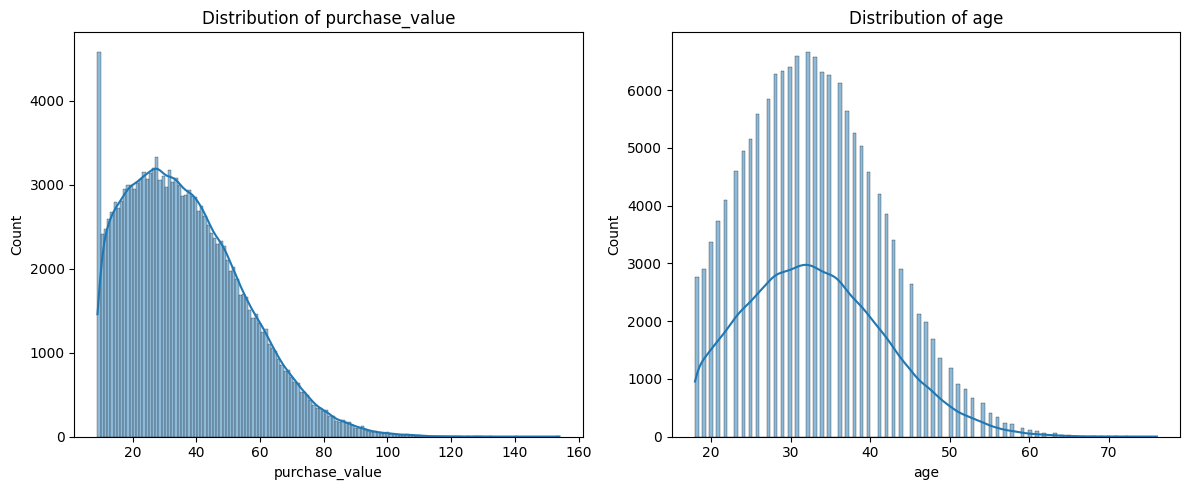

In [9]:
plot_numerical_distributions(
    fraud_df,
    ["purchase_value", "age"]
)

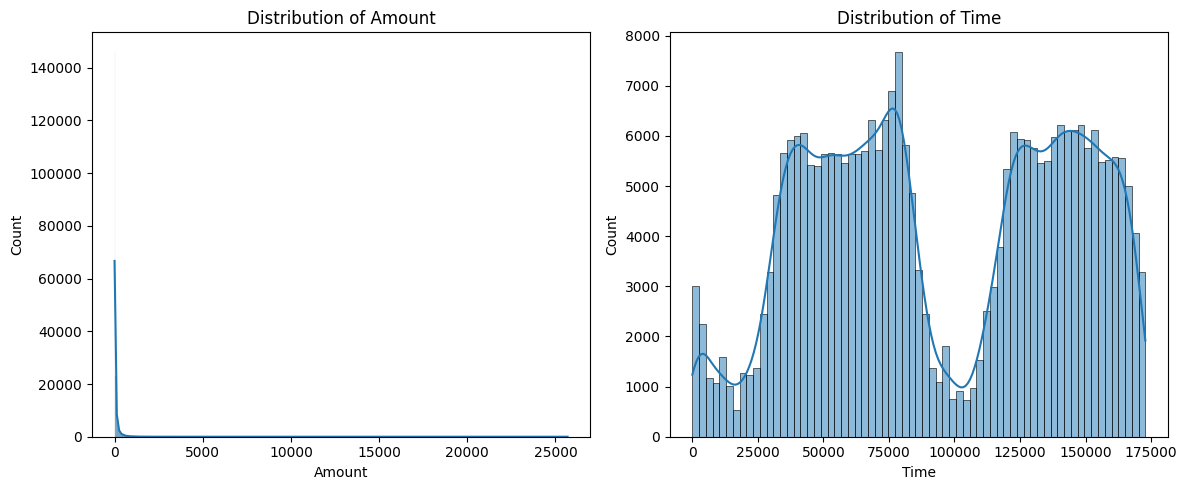

In [10]:
plot_numerical_distributions(
    credit_df,
    ["Amount", "Time"]
)

## Categorical Variables

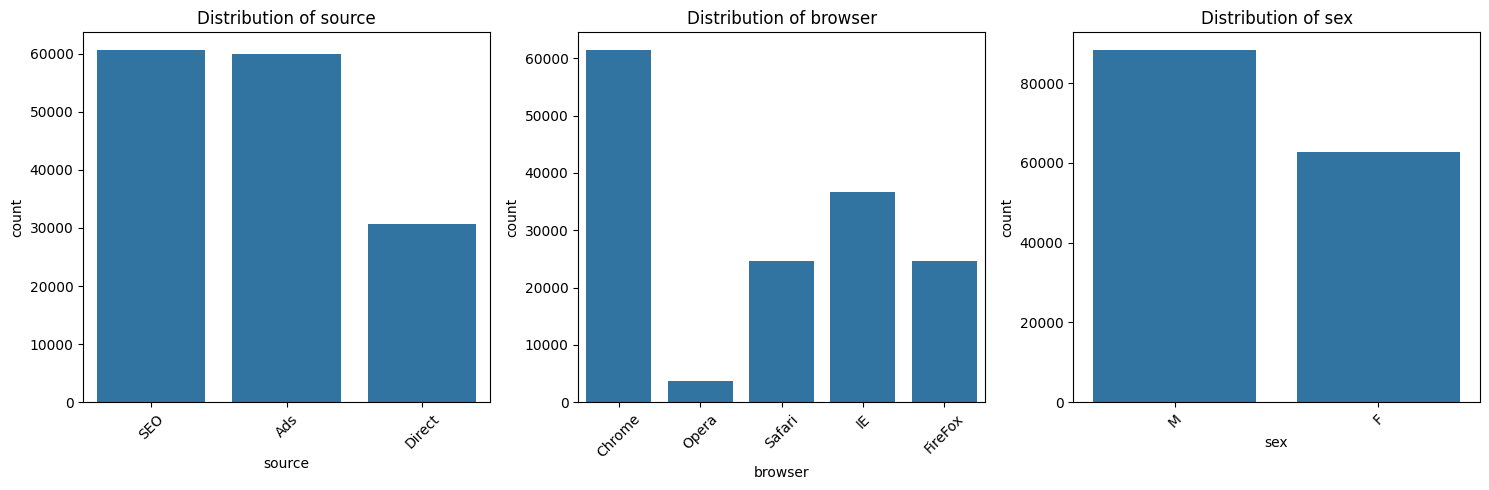

In [11]:
plot_categorical_distributions(
    fraud_df,
    ["source", "browser", "sex"]
)

# Bivariate Analysis
## Numerical Feature vs Fraud

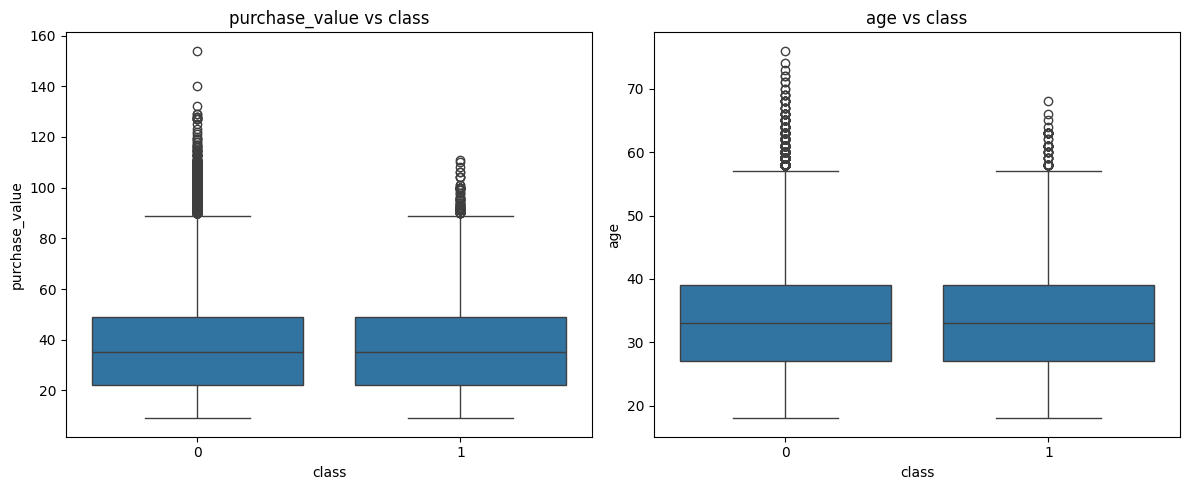

In [12]:
fraud_boxplots(
    fraud_df,
    ["purchase_value", "age"],
    "class"
)

## Categorical Feature vs Fraud

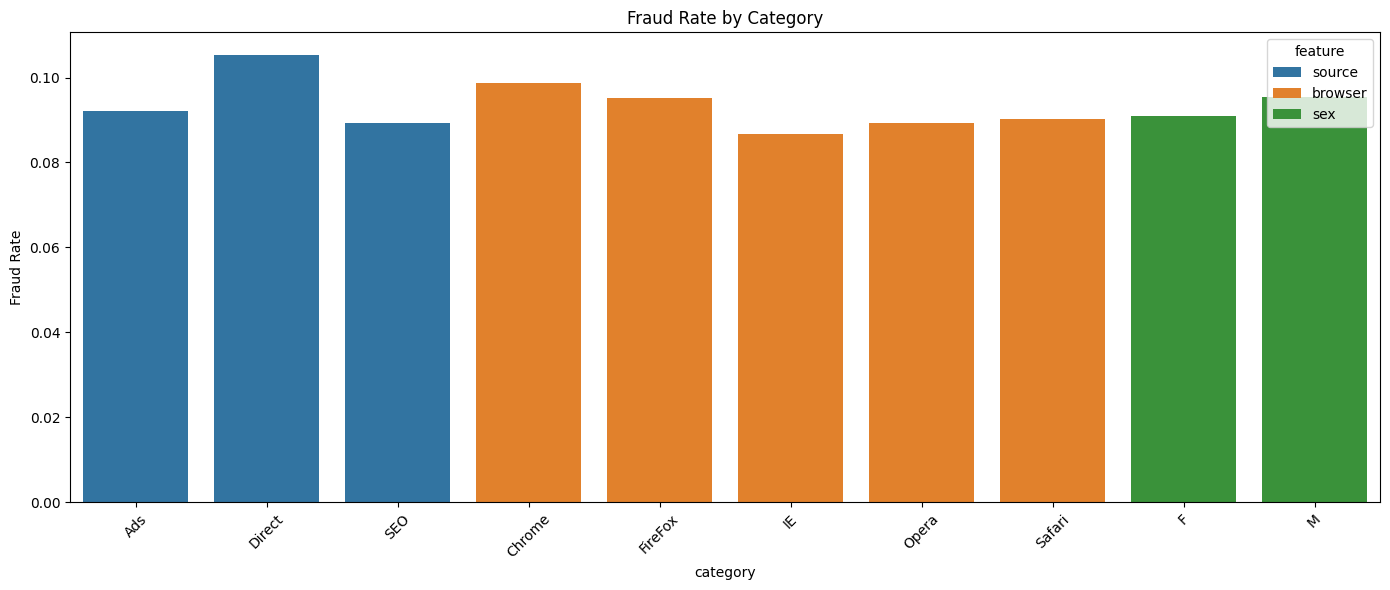

,category,fraud_rate,feature
0,Ads,0.092066,source
1,Direct,0.105370,source
2,SEO,0.089285,source
3,Chrome,0.098792,browser
4,FireFox,0.095165,browser
5,IE,0.086775,browser
6,Opera,0.089227,browser
7,Safari,0.090201,browser
8,F,0.091007,sex
9,M,0.095523,sex


In [13]:
fraud_rate_by_category(
    fraud_df,
    ["source", "browser", "sex"],
    "class"
)

# Fraud Correlation Matrix

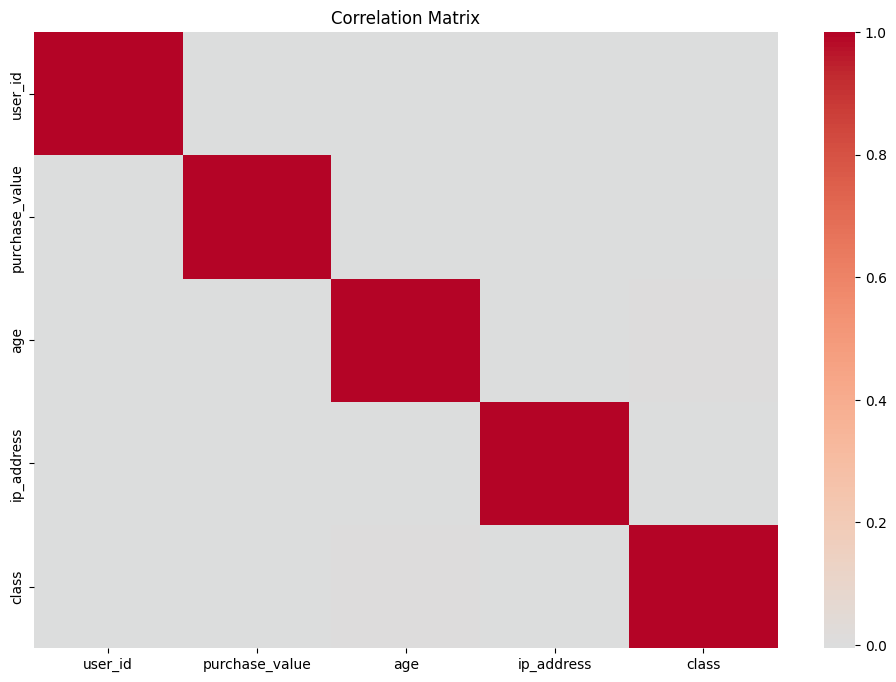

In [14]:
correlation_heatmap(fraud_df)


# Credit Correlation Matrix

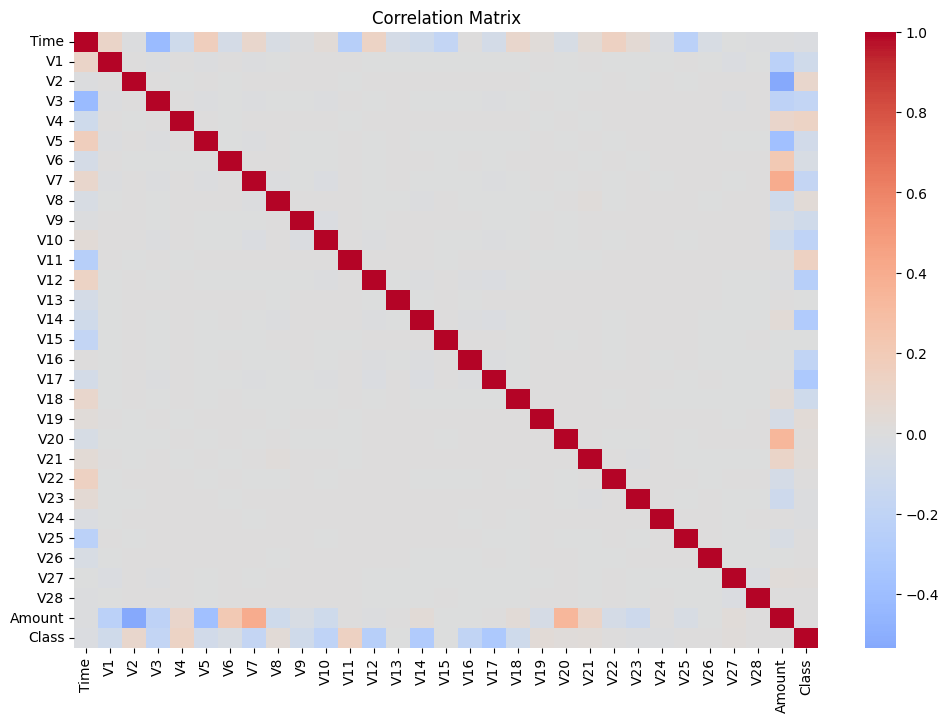

In [15]:
correlation_heatmap(credit_df)

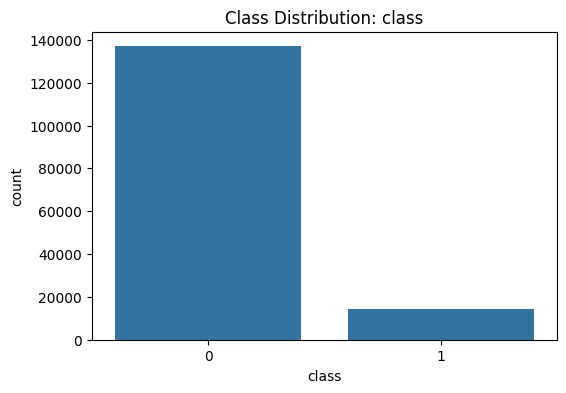


Class Percentages:
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


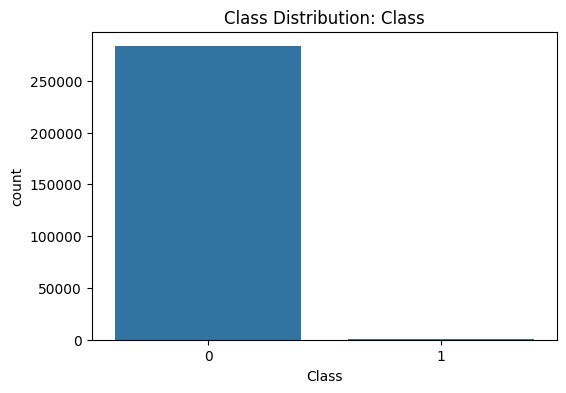


Class Percentages:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [16]:
plot_class_distribution(
    fraud_df,
    "class"
)

plot_class_distribution(
    credit_df,
    "Class"
)

## Prepare IP-Country Dataset

In [17]:
ip_country_df = pd.read_csv(
    "../data/raw/IpAddress_to_Country.csv"
)
# Prepare country mapping data
ip_country_df = prepare_ip_country_data(ip_country_df)
ip_country_df

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216,16777471,Australia
1,16777472,16777727,China
2,16777728,16778239,China
3,16778240,16779263,Australia
4,16779264,16781311,China
...,...,...,...
138841,3758092288,3758093311,Hong Kong
138842,3758093312,3758094335,India
138843,3758095360,3758095871,China
138844,3758095872,3758096127,Singapore


# Merge Fraud Data with IpAddress to Country

In [18]:
fraud_country_df = merge_country_info(
    fraud_df,
    ip_country_df
)

fraud_country_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,16778864,0,16778240.0,16779263.0,Australia
635,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,16842045,0,16809984.0,16842751.0,Thailand
636,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,16843656,0,16843264.0,16843775.0,China
637,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,16938732,0,16924672.0,16941055.0,China
638,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,16971984,0,16941056.0,16973823.0,Thailand


# Fraud Analysis by Country

In [19]:
country_stats = fraud_rate_by_country(
    fraud_country_df
)

country_stats.head(10)

,total_transactions,fraud_transactions,fraud_rate
country,,,
Turkmenistan,1,1,100.000000
Namibia,23,10,43.478261
Sri Lanka,31,13,41.935484
Luxembourg,72,28,38.888889
Virgin Islands (U.S.),3,1,33.333333
Ecuador,106,28,26.415094
Tunisia,118,31,26.271186
Peru,119,31,26.050420
Bolivia,53,13,24.528302


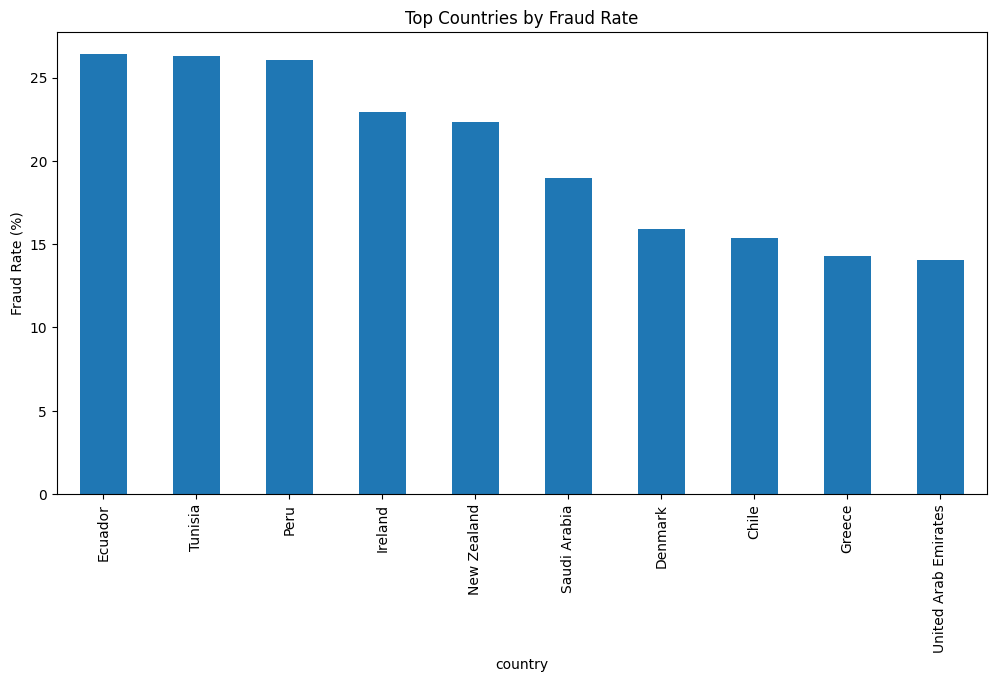

In [20]:
top_10 = (
    country_stats[
        country_stats["total_transactions"] >= 100
    ]
    .head(10)
)

plt.figure(figsize=(12, 6))

top_10["fraud_rate"].plot(
    kind="bar"
)

plt.ylabel("Fraud Rate (%)")
plt.title("Top Countries by Fraud Rate")

plt.show()

# Feature Engineering
## Required temporal and transaction-behavior features

In [21]:
fraud_df = feature_engineering(fraud_df)

In [22]:
fraud_df

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,hour_of_day,day_of_week,time_since_signup_hours,time_since_signup_days,user_transaction_count,transactions_before
116708,2,2015-01-11 03:47:13,2015-02-21 10:03:37,54,FGBQNDNBETFJJ,SEO,Chrome,F,25,880217484,0,10,Saturday,990.273333,41.261389,1,0
15108,4,2015-06-02 16:40:57,2015-09-26 21:32:16,41,MKFUIVOHLJBYN,Direct,Safari,F,38,2785906106,0,21,Saturday,2788.855278,116.202303,1,0
46047,8,2015-05-28 07:53:06,2015-08-13 11:53:07,47,SCQGQALXBUQZJ,SEO,Chrome,M,25,356056736,0,11,Thursday,1852.000278,77.166678,1,0
67650,9,2015-05-16 15:58:32,2015-05-20 23:06:42,62,IEZOHXPZBIRTE,SEO,FireFox,M,21,759104706,0,23,Wednesday,103.136111,4.297338,1,0
109067,12,2015-01-10 06:25:12,2015-03-04 20:56:37,35,MSNWCFEHKTIOY,Ads,Safari,M,19,2985180352,0,20,Wednesday,1286.523611,53.605150,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143144,399992,2015-06-04 17:43:28,2015-09-30 07:19:17,82,CNVFEDSCAWXGS,Direct,Safari,M,59,1549469282,0,7,Wednesday,2821.596944,117.566539,1,0
103577,399993,2015-07-30 03:41:08,2015-10-01 07:16:25,20,XJMTBAKOHKTGR,Direct,IE,F,37,2755338335,0,7,Thursday,1515.588056,63.149502,1,0
6412,399995,2015-03-10 05:19:31,2015-06-05 23:36:56,33,RYXNXTOXIYRQG,Direct,FireFox,F,35,3701447303,0,23,Friday,2106.290278,87.762095,1,0
139579,399997,2015-06-30 09:02:16,2015-10-07 20:56:54,66,XFNGDCCMMBTCB,Direct,Chrome,M,48,3454704355,0,20,Wednesday,2387.910556,99.496273,1,0


# One-Hot Encode Categorical Features

In [25]:
categorical_cols = [
    "source",
    "browser",
    "sex"
]
fraud_df = encode_categorical_features(
    fraud_df,
    categorical_cols
)

# Scale Numerical Features

In [27]:
numerical_cols = [
    "purchase_value",
    "age"
]
fraud_df, scaler = scale_numerical_features(
    fraud_df,
    numerical_cols
)

In [28]:
from sklearn.model_selection import train_test_split

X = fraud_df.drop("class", axis=1)
y = fraud_df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
def class_distribution(y, title="Class Distribution"):

    dist = y.value_counts()

    percentage = (
        y.value_counts(normalize=True) * 100
    ).round(2)

    result = dist.to_frame("Count")
    result["Percentage"] = percentage

    print(f"\n{title}")
    print(result)

    return result

In [30]:
before_dist = class_distribution(
    y_train,
    "Before SMOTE"
)


Before SMOTE
        Count  Percentage
class                    
0      109568       90.64
1       11321        9.36


## Apply SMOTE

In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_numeric = X_train.select_dtypes(
    include=["number"]
)

X_test_numeric = X_test.select_dtypes(
    include=["number"]
)

In [33]:
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_numeric,
    y_train
)

In [35]:
after_dist = class_distribution(
    y_train_resampled,
    "After SMOTE"
)


After SMOTE
        Count  Percentage
class                    
0      109568        50.0
1      109568        50.0
